In [6]:
%matplotlib inline

%config InlineBackend.figure_format = 'retina'

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [13]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

CJK fallback: Microsoft YaHei


### 课堂练习
1. 生成 `y = e^{-x/2} sin(3x)` 的曲线，设置标题/标签/网格；给出 `x∈[0,10]`。  

用虚线，并画出图例

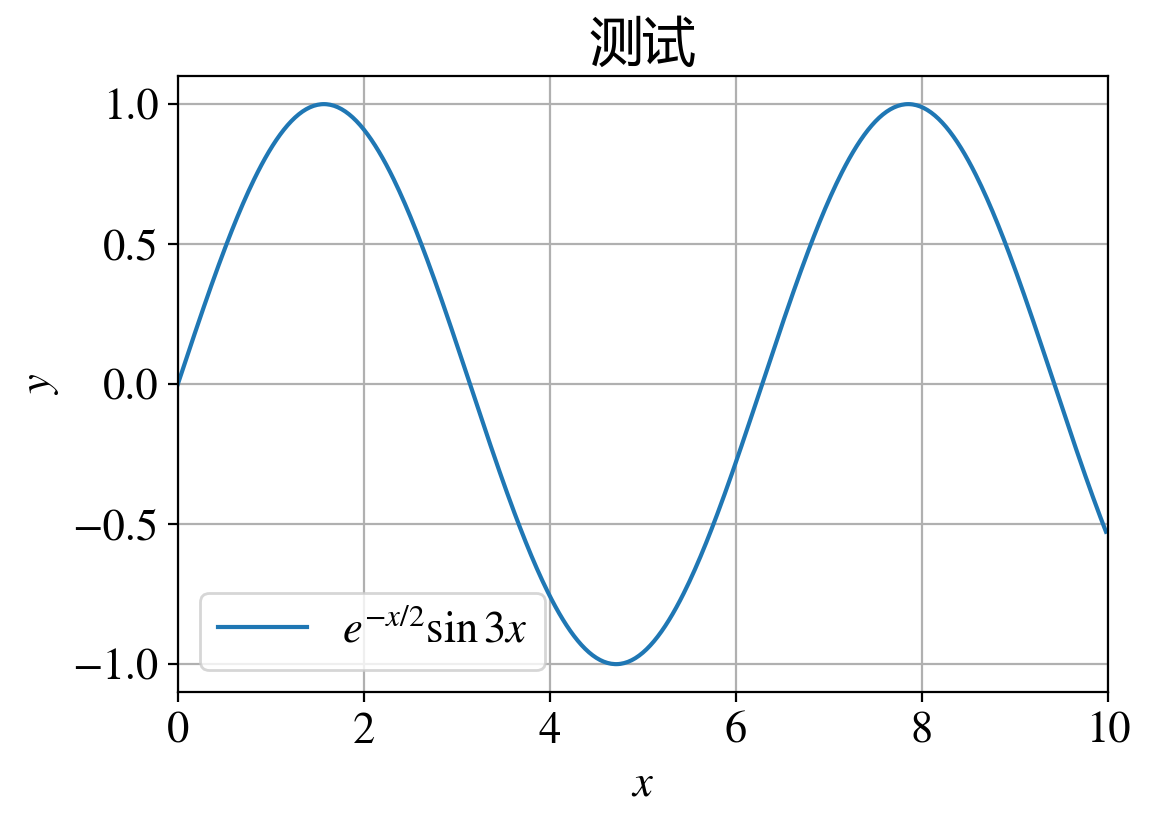

In [16]:
## 你的代码 1

x = np.arange(0, 10, 0.02 )
y = np.exp(-x/2) * np.sin(3*x)

fig, ax = plt.subplots(figsize=(6,4))

## 你的代码

ax.plot(x, np.sin(x), label=r'$e^{-x/2} \sin 3x$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

ax.set_title("测试")
ax.legend()

ax.set_xlim(0, 10)
ax.grid()


Text(0, 0.5, '业绩')

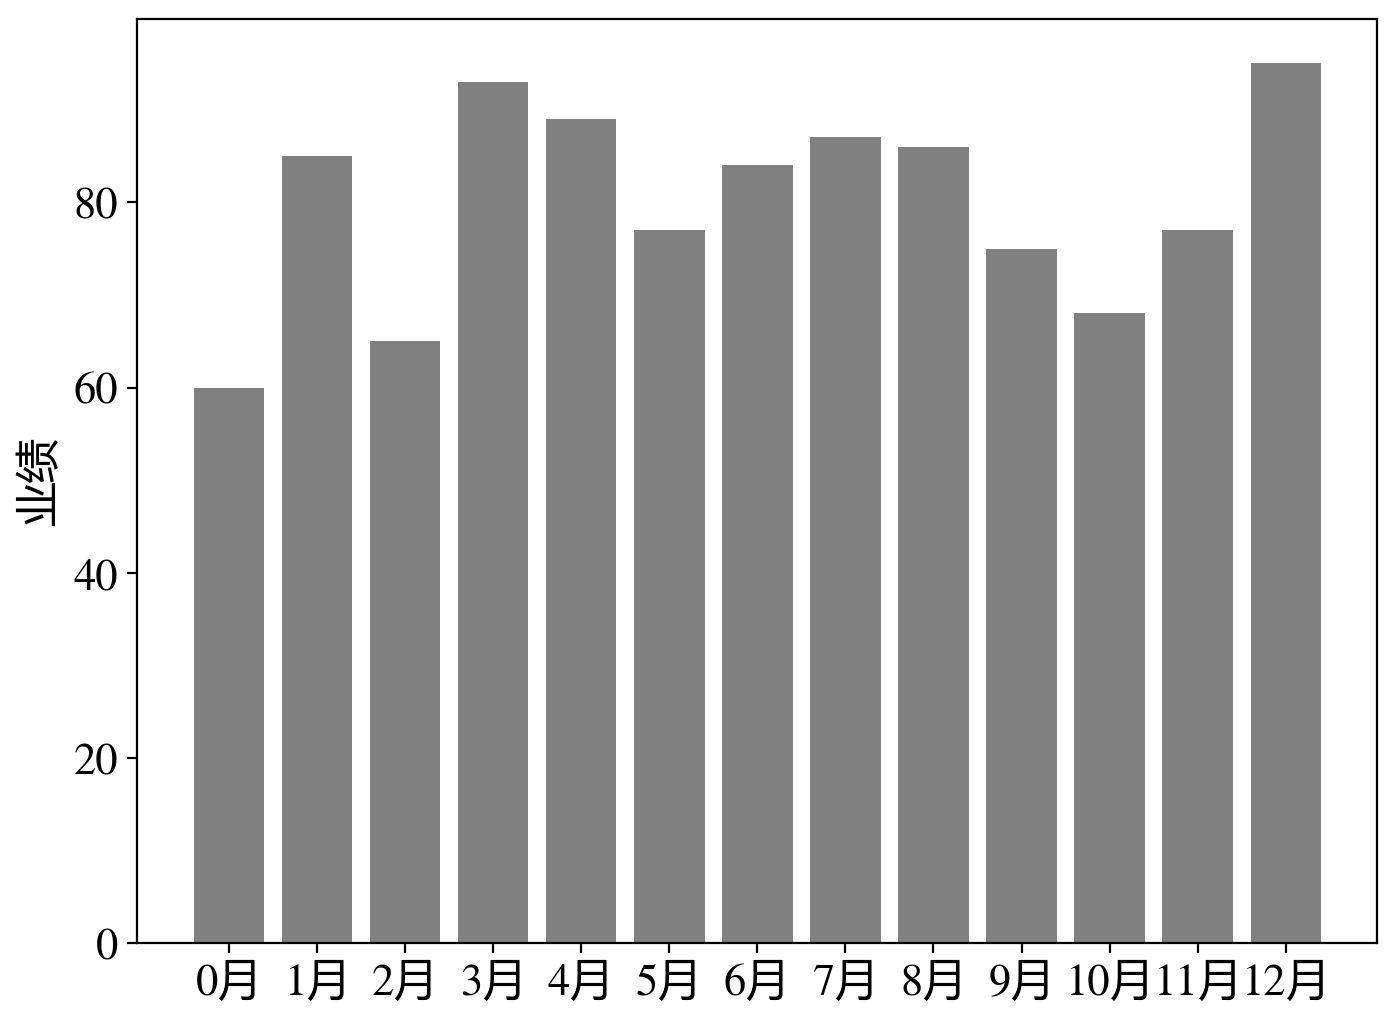

In [19]:
## 课堂练习

months = []
for _k in range(13):
    months.append(f'{_k}月')

values = np.random.randint(60, 100, len(months) )

## 用柱状图画出12个月的柱状图，颜色用 grey，纵轴为“业绩”。

## 你的代码

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(months, values, color='grey')
ax.set_ylabel('业绩')

### 课堂练习

画给定分数的直方图，分析这些分数中有分数的中位数，超过80分以上的有多少比例？


分数的中位数：77.0
超过80分的比例：45.00%


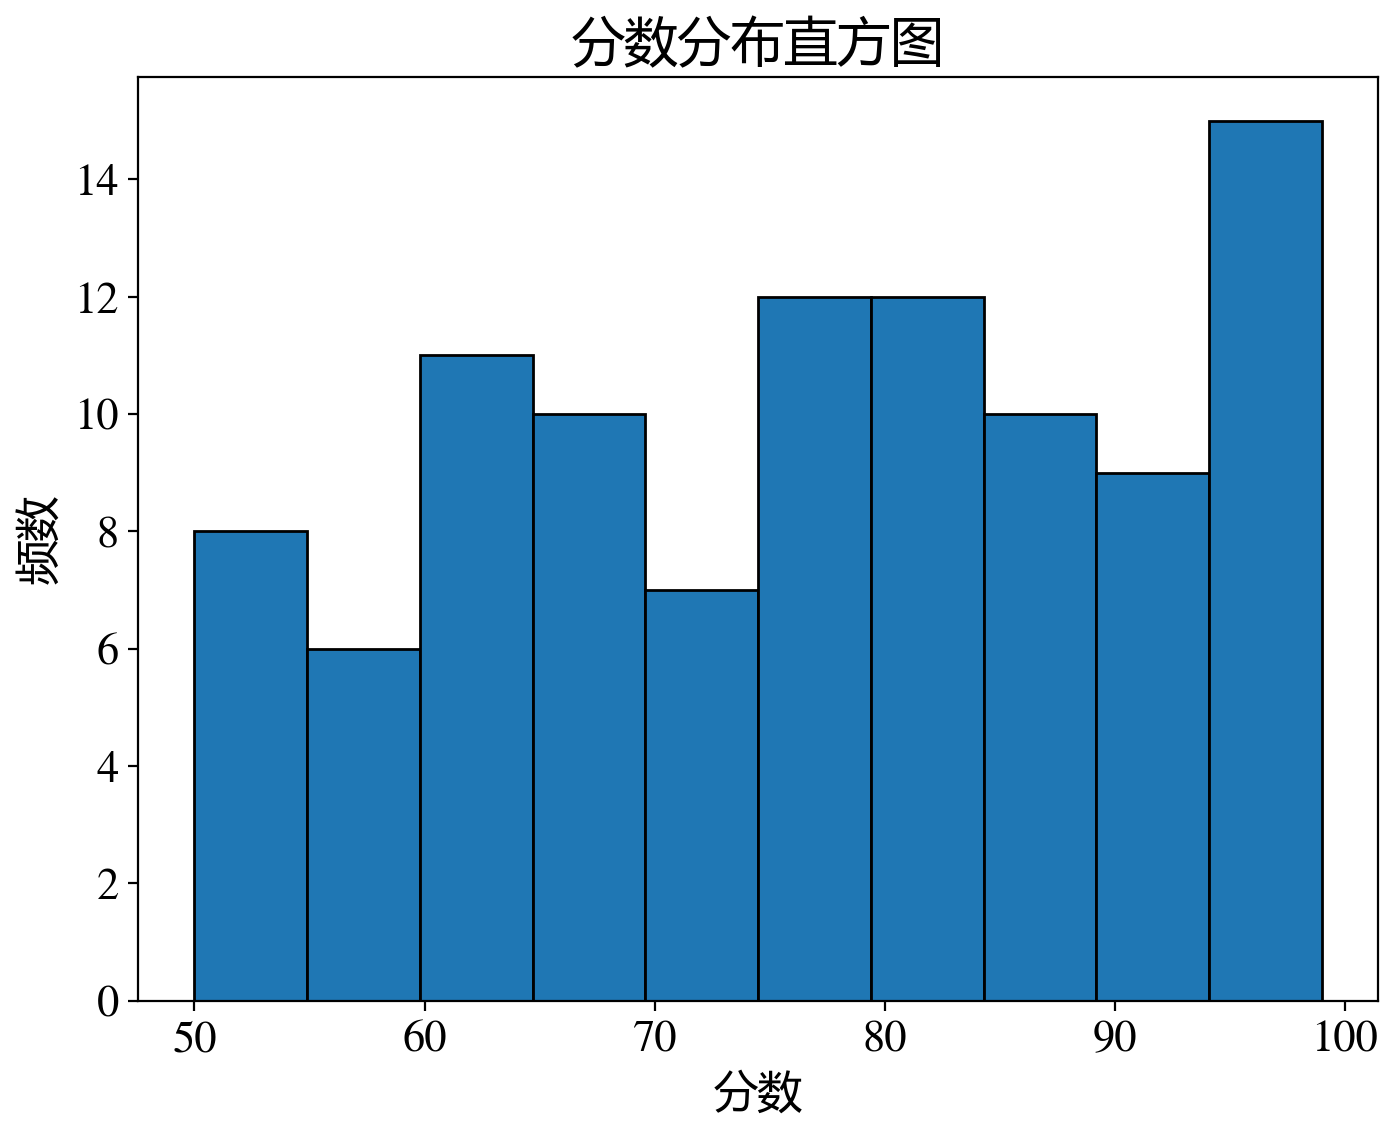

In [24]:
## 100 个分数
scores = np.random.randint(50, 100, 100)

fig, ax = plt.subplots(figsize=(8, 6))

## 你的代码

ax.hist(scores, bins=10, edgecolor='black')
ax.set_title('分数分布直方图')
ax.set_xlabel('分数')
ax.set_ylabel('频数')

# 计算中位数
scores_sorted = np.sort(scores)
median = (scores_sorted[49] + scores_sorted[50]) / 2  # 100个数的中位数为第50和第51个数的平均值

# 计算超过80分的比例
proportion_over_80 = sum(scores > 80) / len(scores)

# 输出结果
print(f"分数的中位数：{median}")
print(f"超过80分的比例：{proportion_over_80:.2%}")

plt.show()



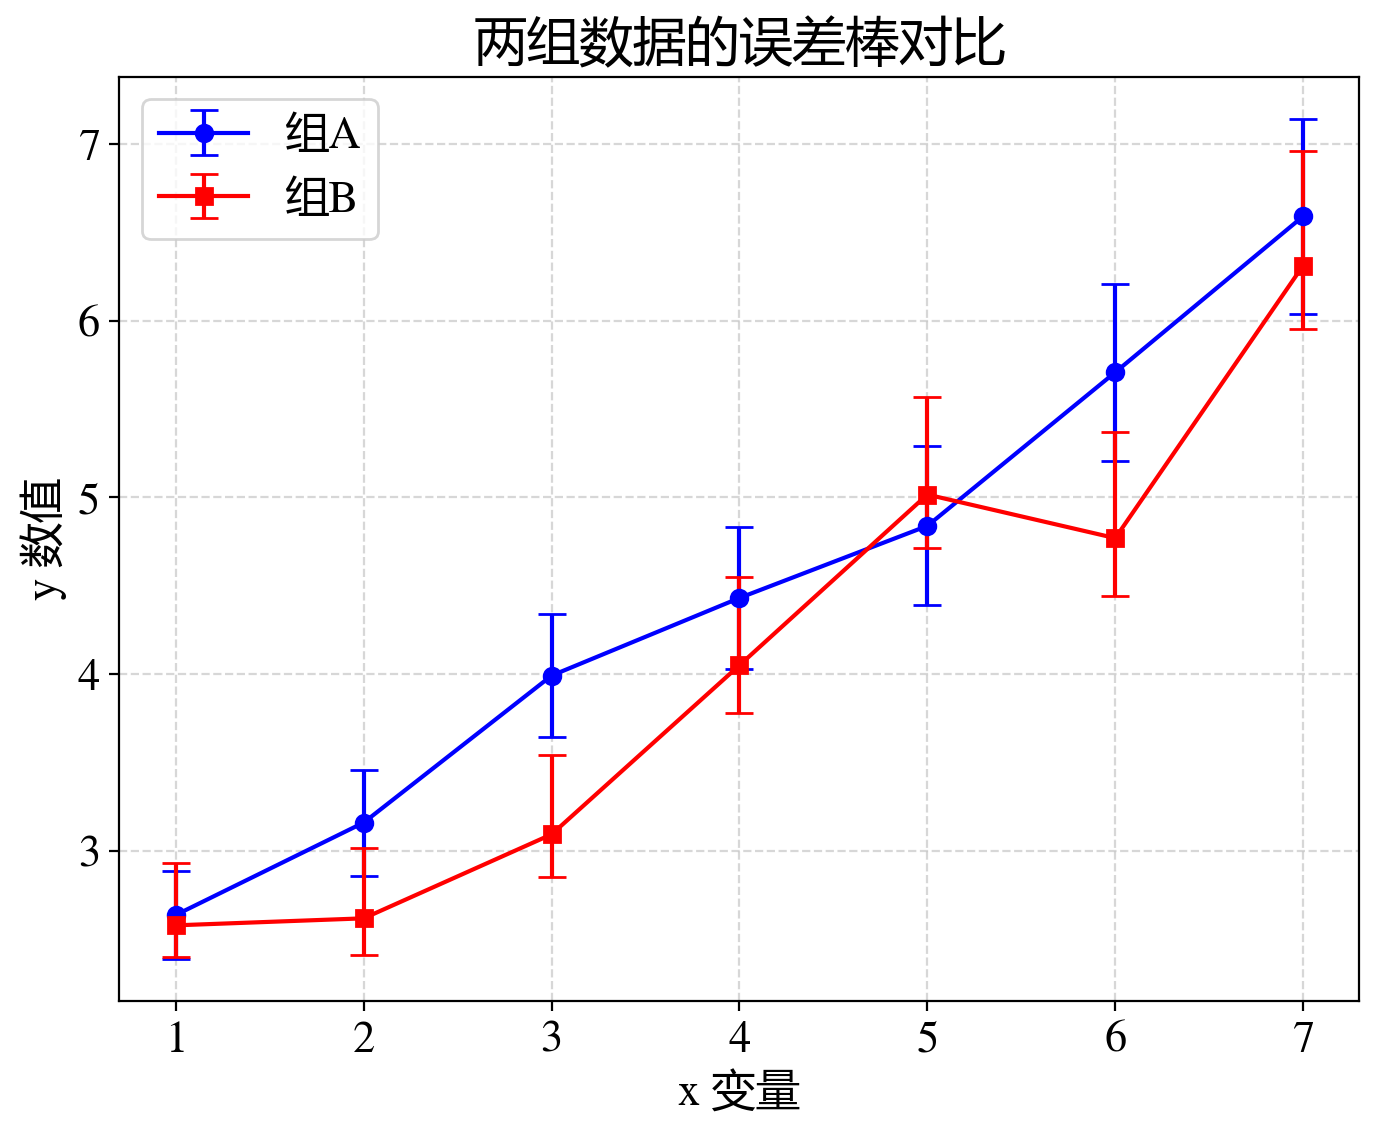

In [29]:
rng = np.random.default_rng(0)
x = np.arange(1, 8)
yA = 2.0 + 0.6*x + rng.normal(0, 0.3, size=x.size)     # 组A
yB = 1.5 + 0.7*x + rng.normal(0, 0.4, size=x.size)     # 组B

# 对称误差（标准误）示意
yA_err = 0.2 + 0.05*x
# 非对称误差：上界更大
yB_err_lower = 0.15 + 0.03*x
yB_err_upper = 0.30 + 0.05*x


## 绘制以上两组数据的误差棒

fig, ax = plt.subplots(figsize=(8, 6))

## 你的代码

# 绘制组A（对称误差棒）
ax.errorbar(x, yA, yerr=yA_err, fmt='o-', label='组A', color='blue', capsize=5)
# 绘制组B（非对称误差棒）
ax.errorbar(x, yB, yerr=[yB_err_lower, yB_err_upper], fmt='s-', label='组B', color='red', capsize=5)

# 图表样式设置
ax.set_title('两组数据的误差棒对比')
ax.set_xlabel('x 变量')
ax.set_ylabel('y 数值')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 课堂练习
1. 在上图中的 `x=π` `y=0`处添加注释箭头，说明“零交点”。  
2. 将图保存为 `my_plot.pdf` 并检查大小与清晰度。


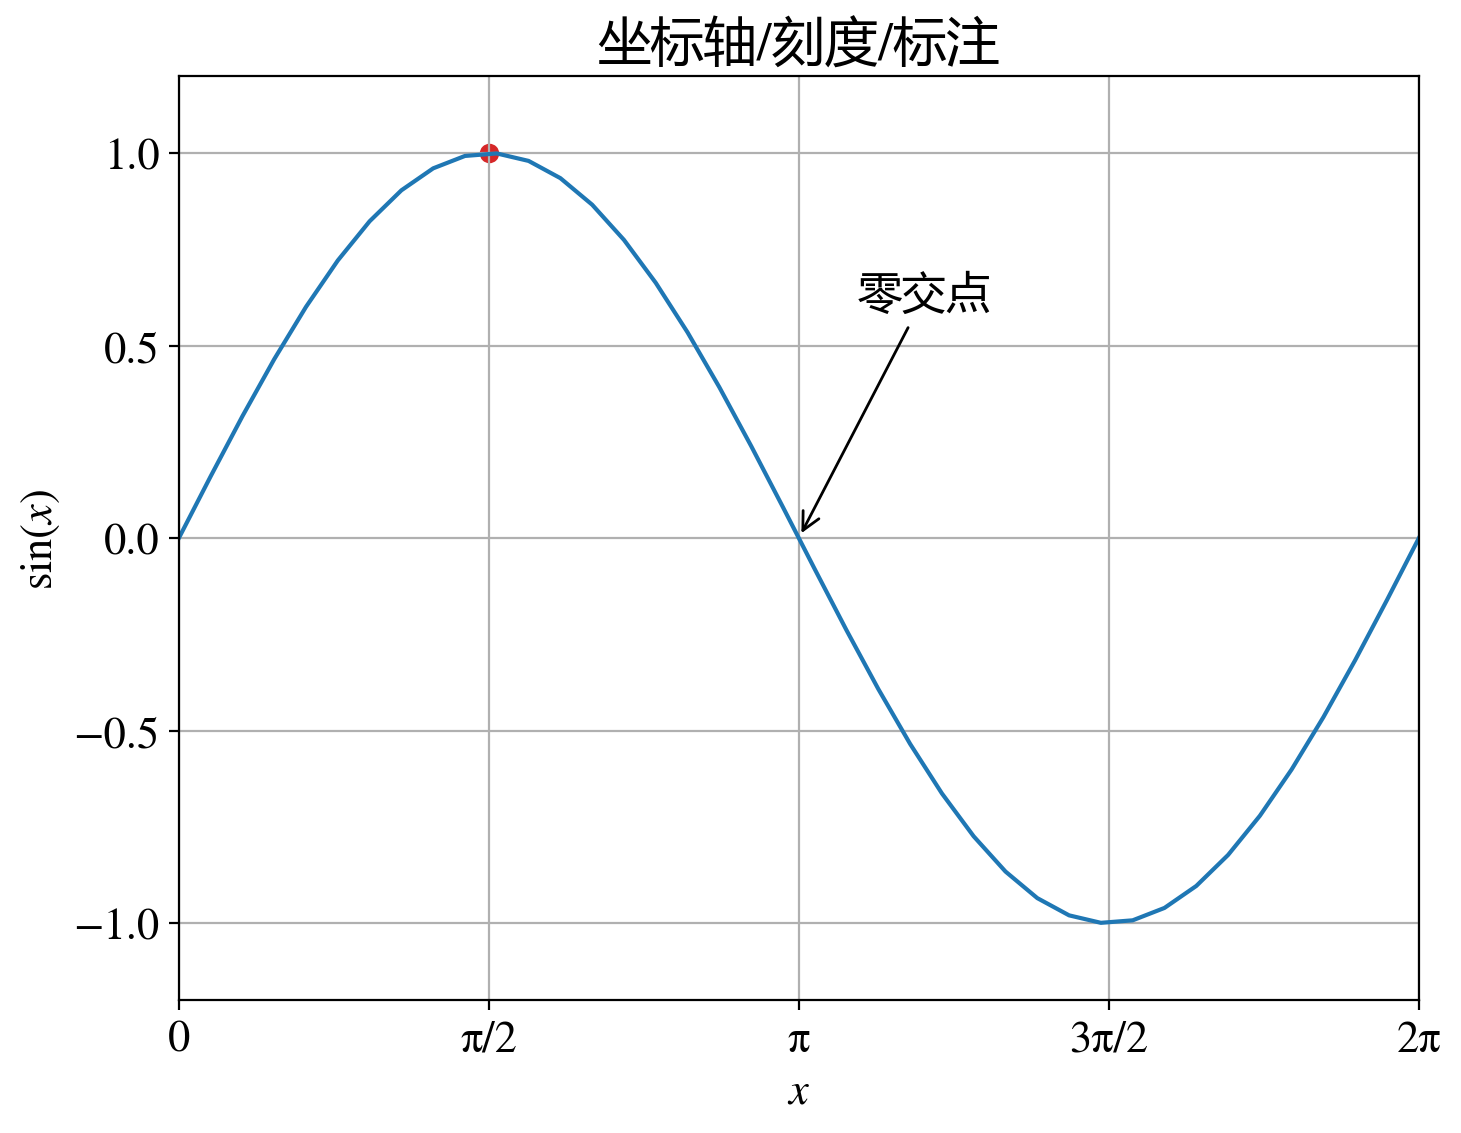

In [31]:
## 你的代码 
fig, ax = plt.subplots(figsize=(8, 6))

x = np.linspace(0, 2*np.pi, 40)

ax.plot(x, np.sin(x))

## x轴范围
ax.set_xlim(0, 2*np.pi)

## y轴范围
ax.set_ylim(-1.2, 1.2)

## x轴的刻度标记
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
              ['0', 'π/2', 'π', '3π/2', '2π'])

ax.set_title("坐标轴/刻度/标注")
ax.set_xlabel("$x$")
ax.set_ylabel("sin($x$)")

# 添加注释
xm = np.pi/2
## 在该坐标点(xm, 1)添加散点
ax.scatter([xm],[1], color='tab:red')

## 添加标注 xy点为指向点，xytext为标注文字点
ax.annotate("零交点", xy=(np.pi,0), xytext=(np.pi+0.3,0.6),
            arrowprops=dict(arrowstyle="->"))
ax.grid(True)
fig, ax = plt.subplots()

ax.plot(x, np.sin(x))

ax.set_title("保存示例")

plt.savefig("my_plot.pdf", dpi=300, bbox_inches='tight')

plt.close(fig)


### 课堂练习

- 在上面的对数图中，画出 `x=0.2`, `x=2`, `x=20` 的纵线
- 在对数图中标出点 (x=20, y=20)
- 

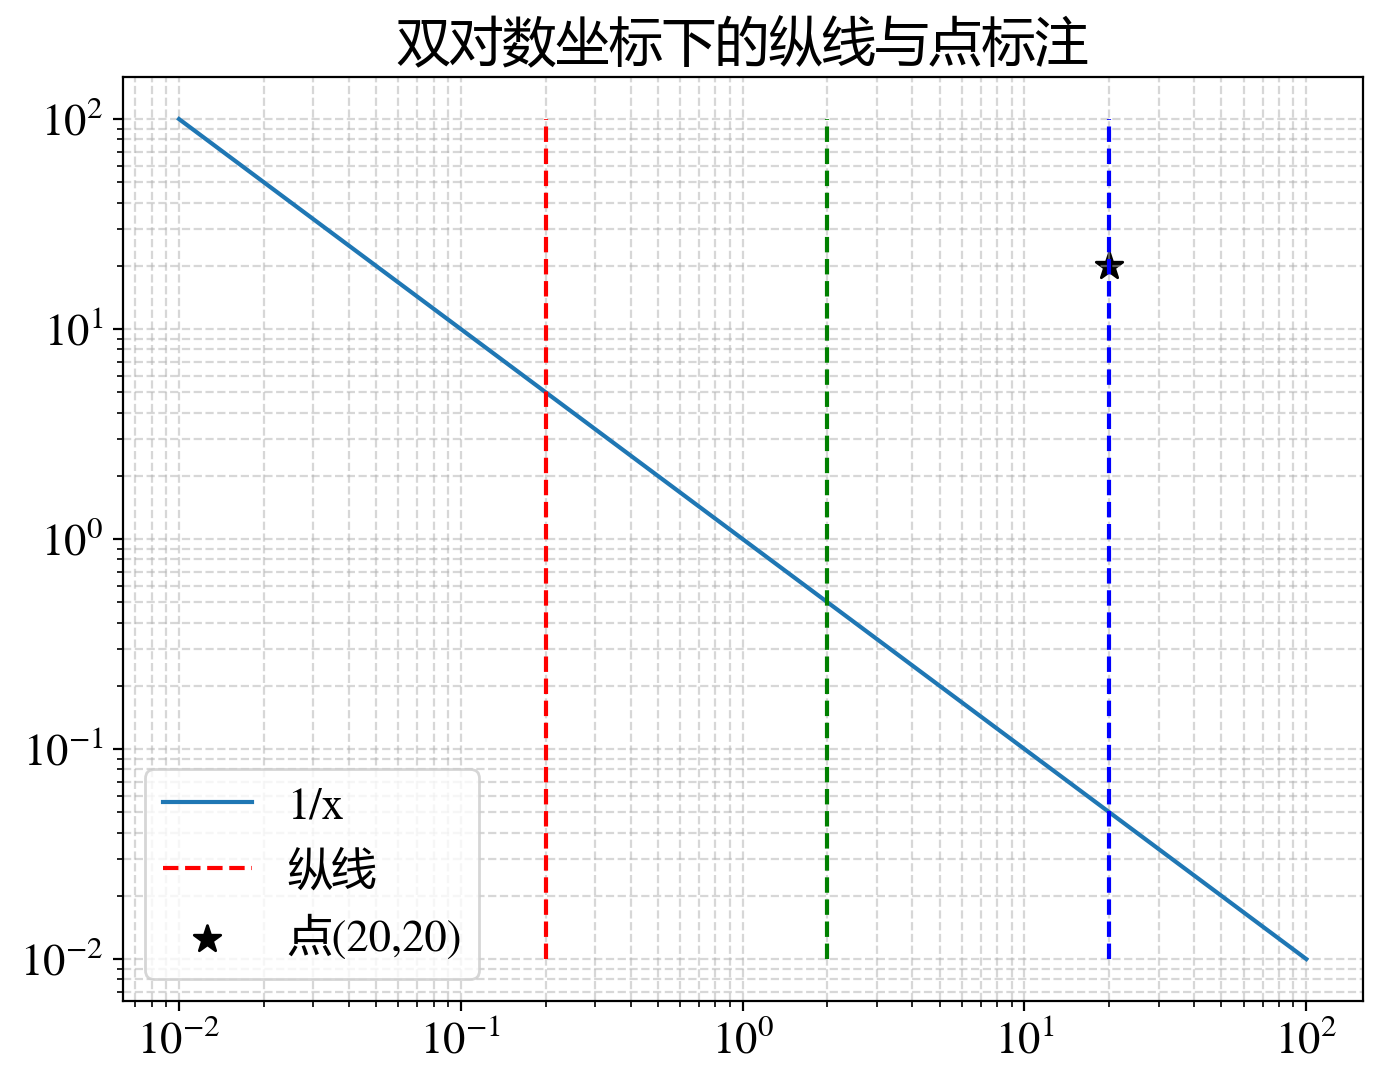

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 生成对数区间数据
xx = np.logspace(-2, 2, 200)
y = 1 / xx  # 保持与示例图形逻辑一致

# 创建双对数坐标图
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(xx, y, label='1/x')
ax.set_xscale('log')  # x轴设为对数坐标
ax.set_yscale('log')  # y轴设为对数坐标
ax.set_title('双对数坐标下的纵线与点标注')
ax.grid(visible=True, which='both', linestyle='--', alpha=0.5)  # 显示网格辅助观察

# 画指定纵线：x=0.2、x=2、x=20
ax.vlines(
    x=[0.2, 2, 20], 
    ymin=np.min(y), 
    ymax=np.max(y), 
    colors=['red', 'green', 'blue'], 
    linestyles='dashed', 
    label='纵线'
)

# 标注点(x=20, y=20)
ax.scatter(20, 20, color='black', s=100, marker='*', label='点(20,20)')

ax.legend()
plt.show()

### 课堂练习
把下面图中的直方图和累积直方图画成双纵坐标
- 左轴y轴是直方图的密度函数
- 右边y轴是累积直方图(非密度函数)

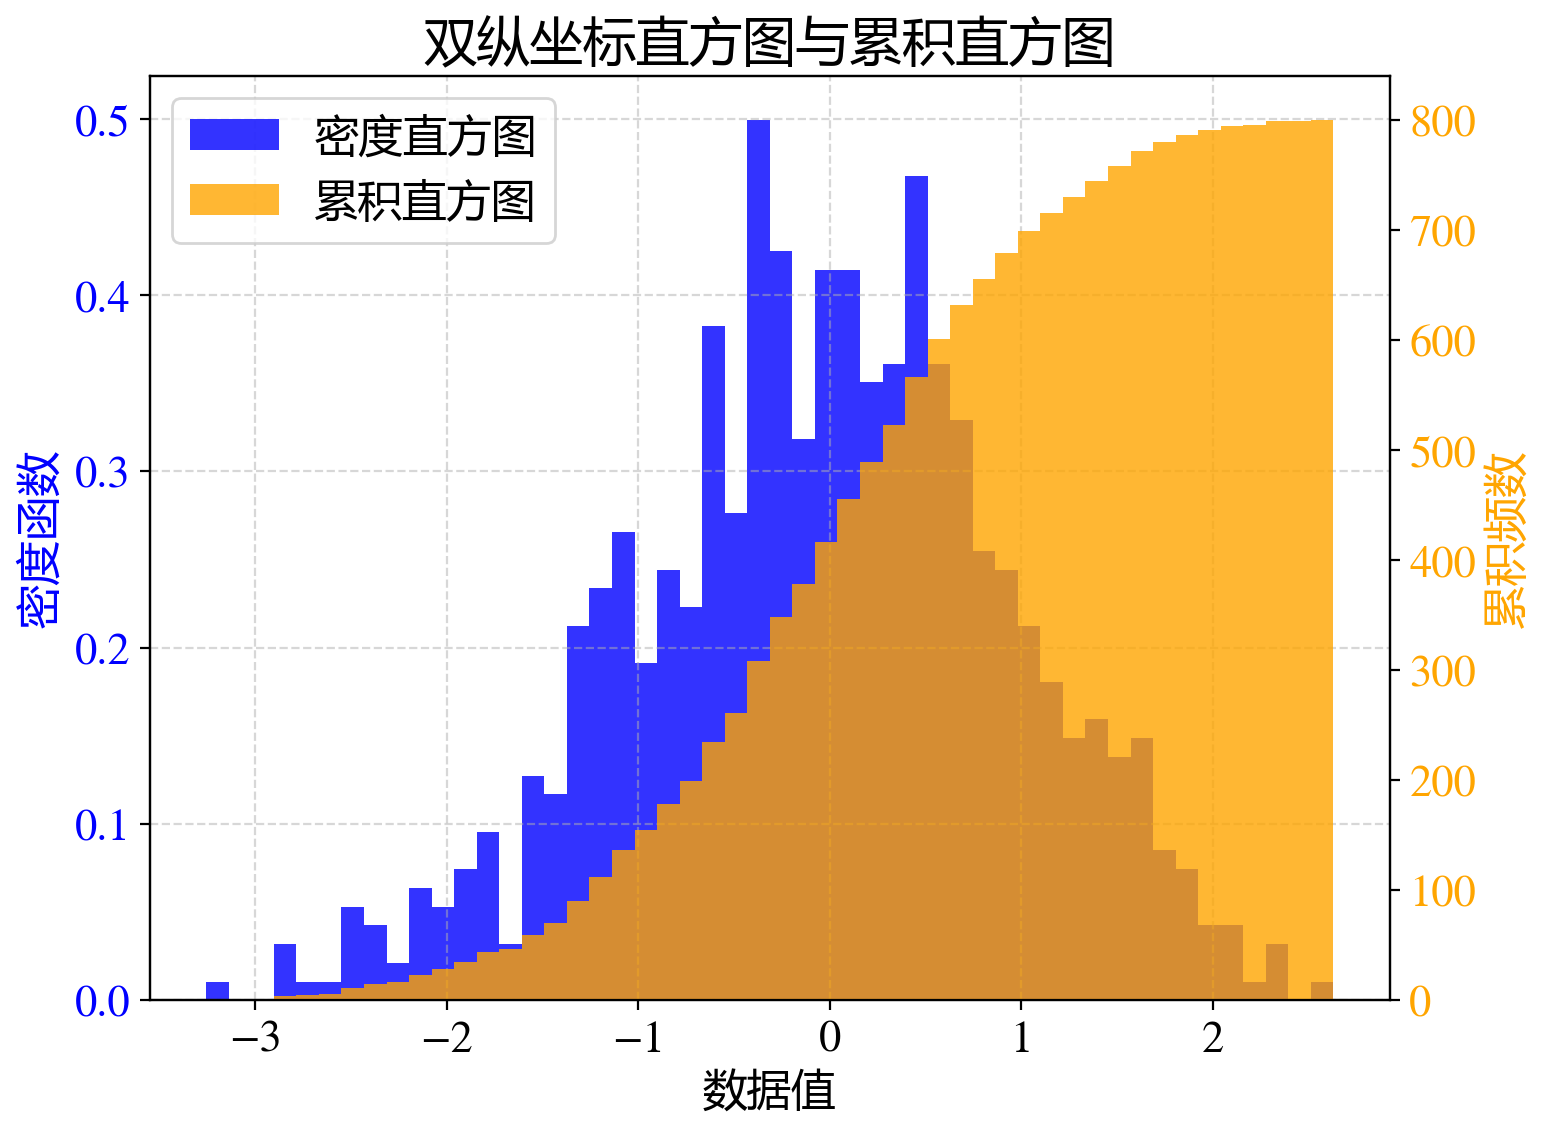

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# 生成正态分布数据
data = np.random.normal(0, 1, 800)

# 创建画布和主坐标轴（左轴，密度函数）
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.hist(data, bins=50, density=True, alpha=0.8, color='blue', label='密度直方图')
ax1.set_ylabel('密度函数', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')  # 左轴刻度与标签颜色设为蓝色

# 创建次坐标轴（右轴，累积直方图，非密度）
ax2 = ax1.twinx()
ax2.hist(data, bins=50, density=False, alpha=0.8, cumulative=True, color='orange', label='累积直方图')
ax2.set_ylabel('累积频数', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')  # 右轴刻度与标签颜色设为橙色

# 图表样式与图例
ax1.set_title('双纵坐标直方图与累积直方图')
ax1.set_xlabel('数据值')
ax1.grid(True, linestyle='--', alpha=0.5)
# 合并两个坐标轴的图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.show()